In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [2]:
movie=pd.read_csv('movie_preprocessed.csv')
movie.head(5)

,Unnamed: 0,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,status,tagline,title,vote_average,vote_count
0,0,15000000.0,"Action,Adventure,Fantasy,Science Fiction",19995.0,"culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...",12.921594,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",10-12-2009,19170001.0,103.0,Released,Enter the World of Pandora.,Avatar,7.2,235.0
1,1,15000000.0,"Adventure,Fantasy,Action",285.0,"ocean,drug abuse,exotic island,east india trad...",en,"Captain Barbossa, long believed to be dead, ha...",12.921594,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,19-05-2007,19170001.0,103.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,235.0
2,2,15000000.0,"Action,Adventure,Crime",14629.0,"spy,based on novel,secret agent,sequel,mi6,bri...",en,A cryptic message from Bond’s past sends him o...,12.921594,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",26-10-2015,19170001.0,148.0,Released,A Plan No One Escapes,Spectre,6.3,235.0
3,3,15000000.0,"Action,Crime,Drama,Thriller",49026.0,"dc comics,crime fighter,terrorist,secret ident...",en,Following the death of District Attorney Harve...,12.921594,"Legendary Pictures,Warner Bros,DC Entertainmen...",United States of America,16-07-2012,19170001.0,103.0,Released,The Legend Ends,The Dark Knight Rises,7.6,235.0
4,4,15000000.0,"Action,Adventure,Science Fiction",49529.0,"based on novel,mars,medallion,space travel,pri...",en,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,07-03-2012,19170001.0,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,235.0


In [3]:
credit=pd.read_csv('credit_preprocessed.csv')
credit.head(5)

,Unnamed: 0,movie_id,title,cast,director,editor,production_design,art_direction,costume_design,original_music_composer,director_of_photography
0,0,19995,Avatar,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,Stephen E. Rivkin,Rick Carter,Andrew Menzies,Deborah Lynn Scott,James Horner,Mauro Fiore
1,1,285,Pirates of the Caribbean At Worlds End,"Johnny Depp,Orlando Bloom,Keira Knightley,Stel...",Gore Verbinski,Stephen E. Rivkin,Rick Heinrichs,John Dexter,Liz Dann,Hans Zimmer,Dariusz Wolski
2,2,206647,Spectre,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,Lee Smith,Dennis Gassner,Neal Callow,Jany Temime,Thomas Newman,Hoyte van Hoytema
3,3,49026,The Dark Knight Rises,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,Lee Smith,Nathan Crowley,Robert Woodruff,Lindy Hemming,Hans Zimmer,Wally Pfister
4,4,49529,John Carter,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,Eric Zumbrunnen,Nathan Crowley,Robert Woodruff,Mayes C. Rubeo,Unknown,Daniel Mindel


# A movie can be rated as "Good", Average', or ' Poor' based on appropriate factors or features available in the data.

Mean vote_average: 6.226462627524464
Model Accuracy Score: 0.624
Model Precision Score: 0.626
Model Recall Score: 0.624
Model f1 Score: 0.622


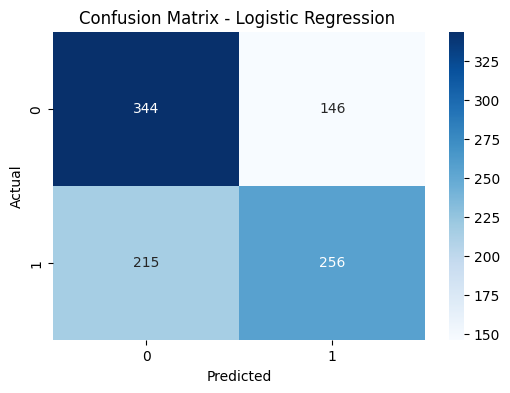

In [4]:
movie['genres_list'] = movie['genres'].apply(lambda x: [g.strip() for g in str(x).split(',')])
movie['production_companies_list'] = movie['production_companies'].apply(lambda x: [p.strip() for p in str(x).split(',')])
movie['production_countries_list'] = movie['production_countries'].apply(lambda x: [c.strip() for c in str(x).split(',')])

movie['genre_count'] = movie['genres_list'].apply(len)

le_country = LabelEncoder()
movie['production_country_encoded'] = le_country.fit_transform(movie['production_countries_list'].astype(str))

le_company = LabelEncoder()
movie['production_companies_encoded'] = le_company.fit_transform(movie['production_companies_list'].astype(str))

le_lang = LabelEncoder()
movie['language_encoded'] = le_lang.fit_transform(movie['original_language'].astype(str))

M = movie['vote_average'].mean()
print("Mean vote_average:", M)

def classify_rating(v):
    if v > M:
        return 'Good'
    elif v >= M/2 and v <= M:
        return 'Average'
    else:
        return 'Poor'

movie['rating_class'] = movie['vote_average'].apply(classify_rating)


features = [
    'budget',
    'runtime',
    'genre_count',
    'production_country_encoded',
    'language_encoded',
    'production_companies_encoded'
]
X=movie[features]
y = movie['rating_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy Score: {acc:.3f}")

pre = precision_score(y_test, y_pred,average='weighted')
print(f"Model Precision Score: {pre:.3f}")

rec = recall_score(y_test, y_pred,average='weighted')
print(f"Model Recall Score: {rec:.3f}")

f1 = f1_score(y_test, y_pred,average='weighted')
print(f"Model f1 Score: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression ")
plt.show()


# Can we predict the movie rating using only the budget

In [6]:
X = movie[['budget']]   
y = movie['vote_average']          

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Model Evaluation ===")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

print("\n=== Model Coefficients ===")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient : {model.coef_[0]:.3f}")


=== Model Evaluation ===
Mean Absolute Error (MAE): 0.667
Root Mean Squared Error (RMSE): 0.720
R² Score: 0.000

=== Model Coefficients ===
Intercept: 6.227
Coefficient : -0.000


# Cluster top-rated movies to identify distinct segments of high-performing films

Mean vote_average: 6.226462627524464


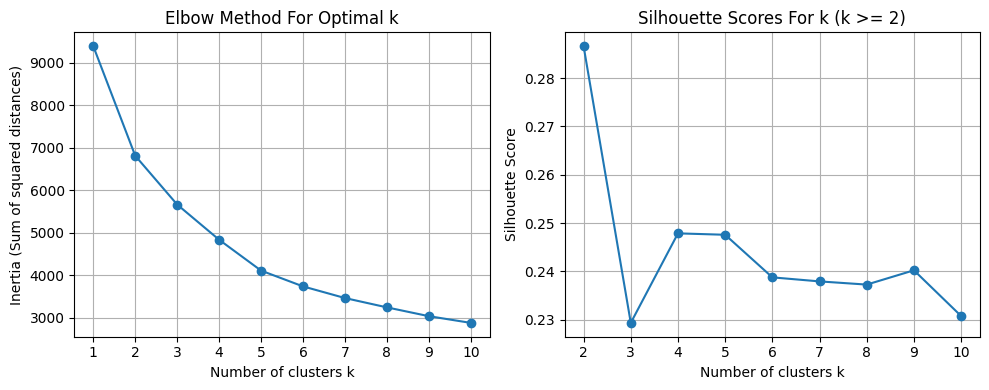

Best k by silhouette score: 2 (silhouette=0.2866)

Cluster counts:
cluster
0    1476
1     873
Name: count, dtype: int64


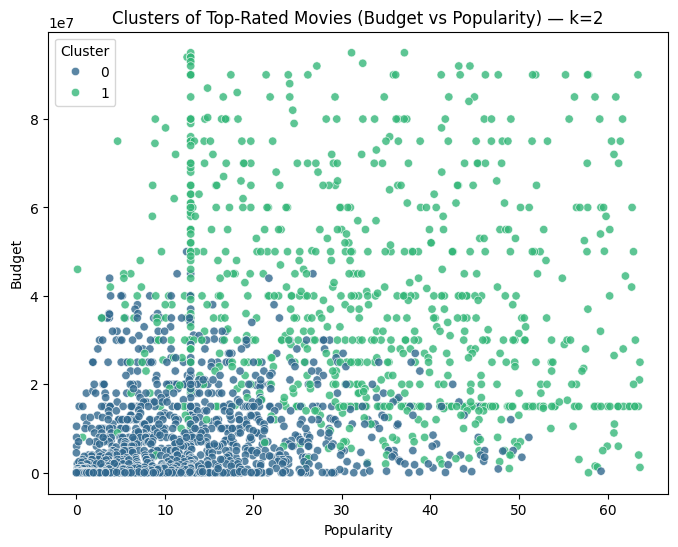


=== Cluster Feature Averages ===
              budget  popularity  runtime  genre_count
cluster                                               
0         8145940.80       11.81   104.82         2.26
1        38265803.09       32.12   118.61         2.98


In [8]:
M = movie['vote_average'].mean()
print("Mean vote_average:", M)
top_movies = movie[movie['vote_average'] > M].copy()

features = ['budget', 'popularity', 'runtime', 'genre_count']
X = top_movies[features].dropna()

max_k = 10
inertias = []

sil_scores = []

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
ks = range(1, max_k + 1)
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    if k >= 2:
        labels = kmeans.labels_
        sil = silhouette_score(X_scaled, labels)
        sil_scores.append(sil)
    else:
        sil_scores.append(np.nan)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, marker='o')
plt.xticks(ks)
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(ks[1:], sil_scores[1:], marker='o')  # silhouette from k=2...
plt.xticks(ks[1:])
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores For k (k >= 2)')
plt.grid(True)

plt.tight_layout()
plt.show()


sil_scores_array = np.array(sil_scores[1:])  
best_k_relative = sil_scores_array.argmax() 
best_k = (best_k_relative + 2)
print(f"Best k by silhouette score: {best_k} (silhouette={sil_scores[best_k-1]:.4f})")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
top_movies['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(top_movies['cluster'].value_counts().sort_index())

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=top_movies['popularity'],
    y=top_movies['budget'],
    hue=top_movies['cluster'],
    palette='viridis',
    alpha=0.8
)
plt.title(f'Clusters of Top-Rated Movies (Budget vs Popularity) — k={best_k}')
plt.xlabel('Popularity')
plt.ylabel('Budget')
plt.legend(title='Cluster')
plt.show()

cluster_summary = top_movies.groupby('cluster')[features].mean().round(2)
print("\n=== Cluster Feature Averages ===")
print(cluster_summary)

